In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import networkx as nx
from itertools import combinations
import matplotlib as mpl
work_dir = '/Users/oskarsvensson/Science/FILES/ARTICLES/Hst1_self/Hst1_self_asso/analysis/'

cm = 1/2.54
font = 8
font_label = 10
plt.rcParams['font.family'] = 'Helvetica'

colors = ['darkblue', 'aquamarine', 'darkorange']
cmap = LinearSegmentedColormap.from_list('mycmap', colors)
amount = 100
color_list = cmap(np.linspace(0, 1, amount))

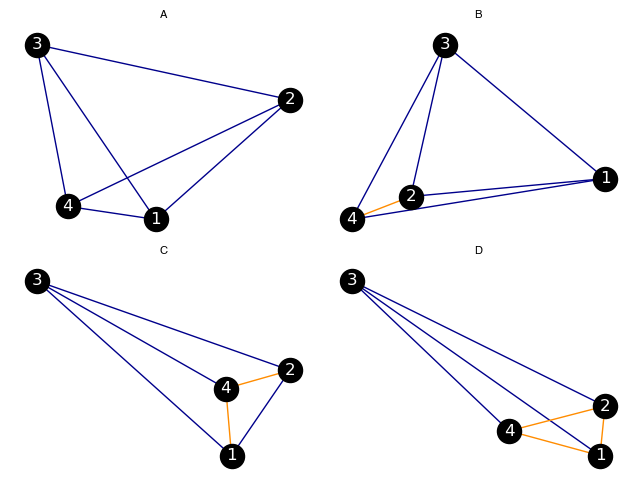

In [6]:
def graph_plot(path, ax1, ax2):
    ax[ax1, ax2].tick_params(labelsize=font)
    G = nx.Graph()
    G.add_nodes_from(range(1, 5))
    pairs = list(combinations(range(1, 5), 2))
    edges = []
    edge_color = []
    weights = []
        
    counter = 0
    for pair in pairs:
        d = np.genfromtxt((path + 'c' + str(pair[0]) + '_' + str(pair[1]) + '.xvg'), 
                          usecols=(1), unpack=True, skip_header=24)
        edges.append((pair[0], pair[1], (1/d[0])))
        weights.append(d[0])
        if d[0] <= 0.225:
            edge_color.append(color_list[-1])
        else:
            edge_color.append(color_list[0])
    
    G.add_weighted_edges_from(edges)
    pos = nx.spring_layout(G, seed=44)
    nx.draw(G, pos, with_labels=True, ax=ax[ax1, ax2], 
            node_color='black',
            edge_color=edge_color,
            font_color='white')

fig, ax = plt.subplots(ncols=2, nrows=2, figsize=((16*cm), (12*cm)), layout='constrained')
graph_plot((work_dir + 'monomer/'), 0, 0)
graph_plot((work_dir + 'dimer/'), 0, 1)
graph_plot((work_dir + 'trimer/'), 1, 0)
graph_plot((work_dir + 'tetramer/'), 1, 1)
ax[0, 0].set_title('A', fontsize=font)
ax[0, 1].set_title('B', fontsize=font)
ax[1, 0].set_title('C', fontsize=font)
ax[1, 1].set_title('D', fontsize=font)
plt.savefig('/Users/oskarsvensson/Desktop/Current/Hst1_asso/New_new_figures/Oligomer_graphs.pdf', dpi=1000)